# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [ ]:
# ======================================
# EKSPERIMEN MSML - WINE QUALITY DATASET
# Nama       : Rahma Hidayati Fitrah
# Email      : rahmahidayatif@gmail.com
# ID Dicoding: APC189D6X0054
# ======================================

"""
PERKENALAN DATASET
------------------
Dataset: Wine Quality (Red + White)
Sumber : UCI Machine Learning Repository
Paper  : Cortez et al., 2009 - Modeling wine preferences by data mining
         from physicochemical properties
URL    : https://archive.ics.uci.edu/dataset/186/wine+quality

Deskripsi:
Dataset ini berisi data fisikokimia wine merah dan putih dari Portugal.
Target: Kualitas wine (score 0-10) berdasarkan uji sensorik.

Fitur (12 input):
- fixed acidity, volatile acidity, citric acid
- residual sugar, chlorides, free sulfur dioxide
- total sulfur dioxide, density, pH, sulphates, alcohol
- type (0 = red wine, 1 = white wine)

Target (1 output):
- quality (score antara 0 dan 10)

Jumlah data: 6.497 baris, 13 kolom
             (1.599 red wine + 4.898 white wine)
Task: Multi-class Classification
"""

print("Perkenalan dataset selesai")

Perkenalan dataset selesai


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport")
print(f"Pandas version    : {pd.__version__}")
print(f"NumPy version     : {np.__version__}")
print(f"Scikit-learn version: ", end="")
import sklearn; print(sklearn.__version__)

Semua library berhasil diimport
Pandas version    : 2.2.2
NumPy version     : 2.0.2
Scikit-learn version: 1.6.1


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
url_red   = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red   = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['type']   = 0
df_white['type'] = 1

df = pd.concat([df_red, df_white], ignore_index=True)

df.to_csv('winequality_raw.csv', index=False)

print("Dataset berhasil dimuat dan disimpan sebagai raw")
print(f"\nJumlah red wine  : {len(df_red)} baris")
print(f"Jumlah white wine: {len(df_white)} baris")
print(f"Total gabungan   : {df.shape[0]} baris, {df.shape[1]} kolom")
print("\n5 baris pertama:")
df.head()

Dataset berhasil dimuat dan disimpan sebagai raw

Jumlah red wine  : 1599 baris
Jumlah white wine: 4898 baris
Total gabungan   : 6497 baris, 13 kolom

5 baris pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
print("INFO DATASET")
df.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
print("MISSING VALUES")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\nDATA DUPLIKAT")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

print("\nSTATISTIK DESKRIPTIF")
df.describe()

MISSING VALUES
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total missing values: 0

DATA DUPLIKAT
Jumlah duplikat: 1177

STATISTIK DESKRIPTIF


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


DISTRIBUSI KELAS TARGET (quality)
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


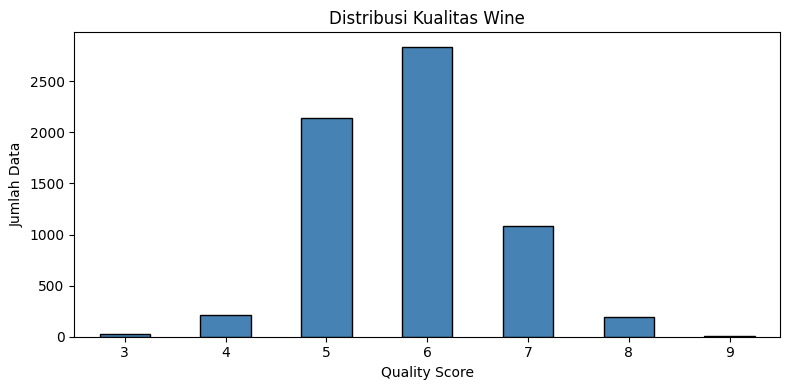

Visualisasi distribusi target disimpan


In [ ]:
print("DISTRIBUSI KELAS TARGET (quality)")
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kualitas Wine')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150)
plt.show()
print("Visualisasi distribusi target disimpan")

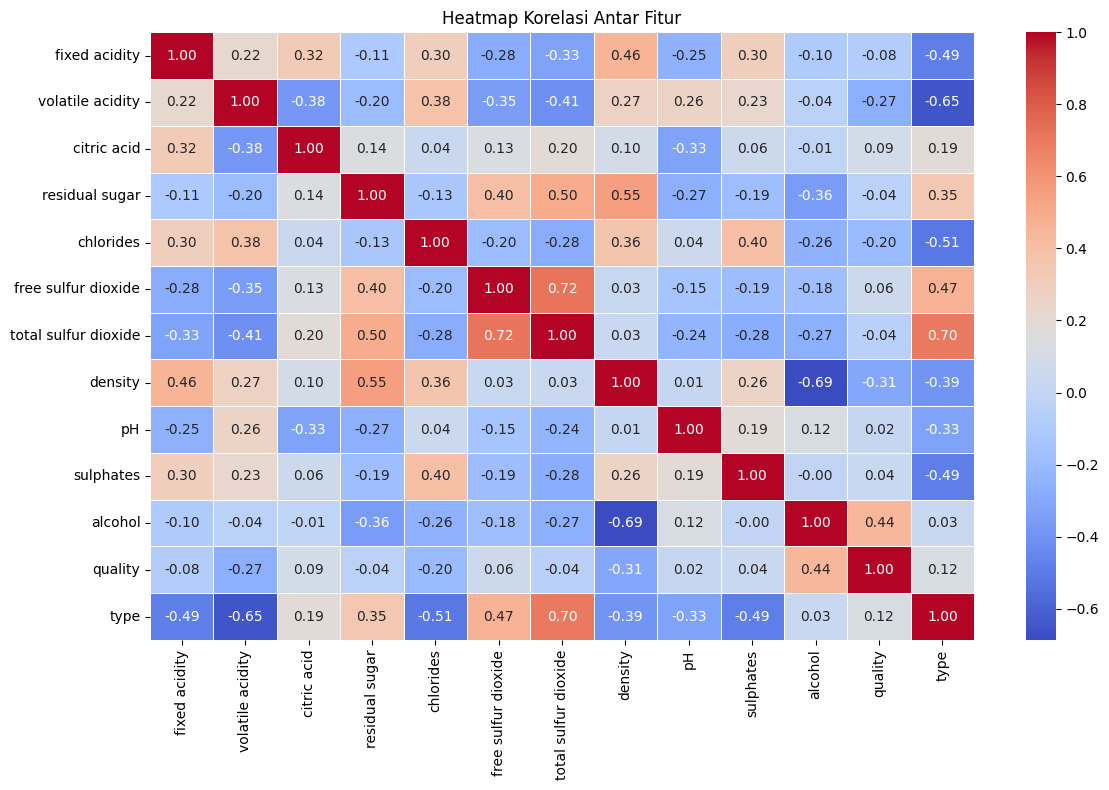

Heatmap korelasi disimpan


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()
print("Heatmap korelasi disimpan")

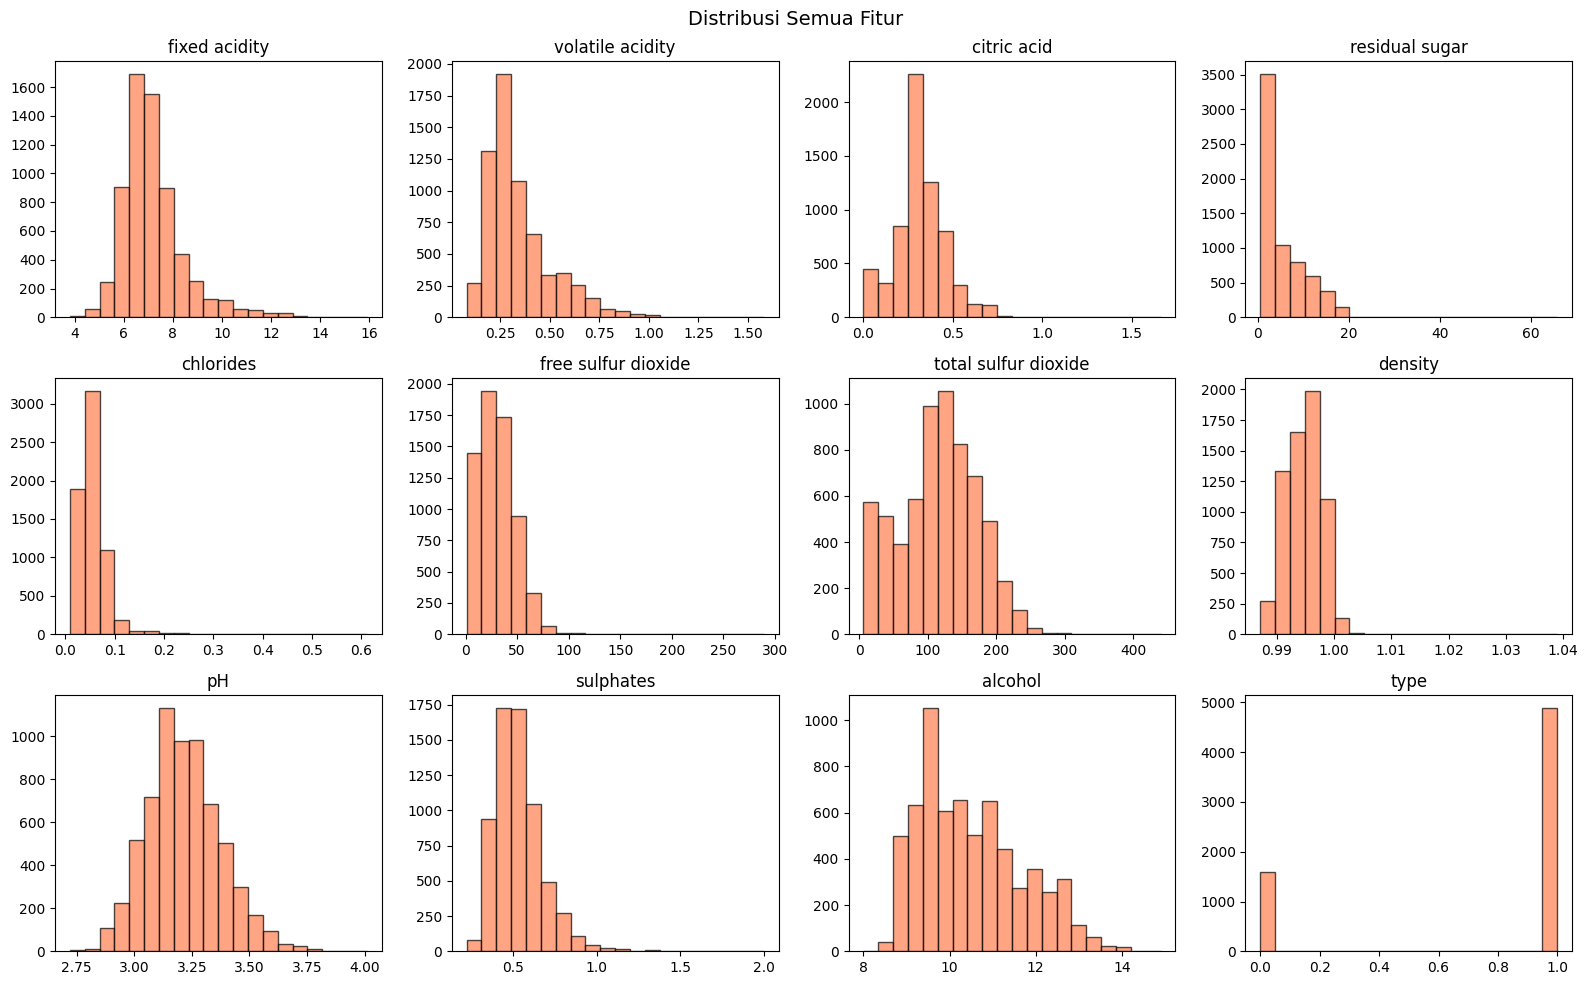

Distribusi semua fitur disimpan


In [ ]:
feature_cols = [col for col in df.columns if col != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)

plt.suptitle('Distribusi Semua Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150)
plt.show()
print("Distribusi semua fitur disimpan")

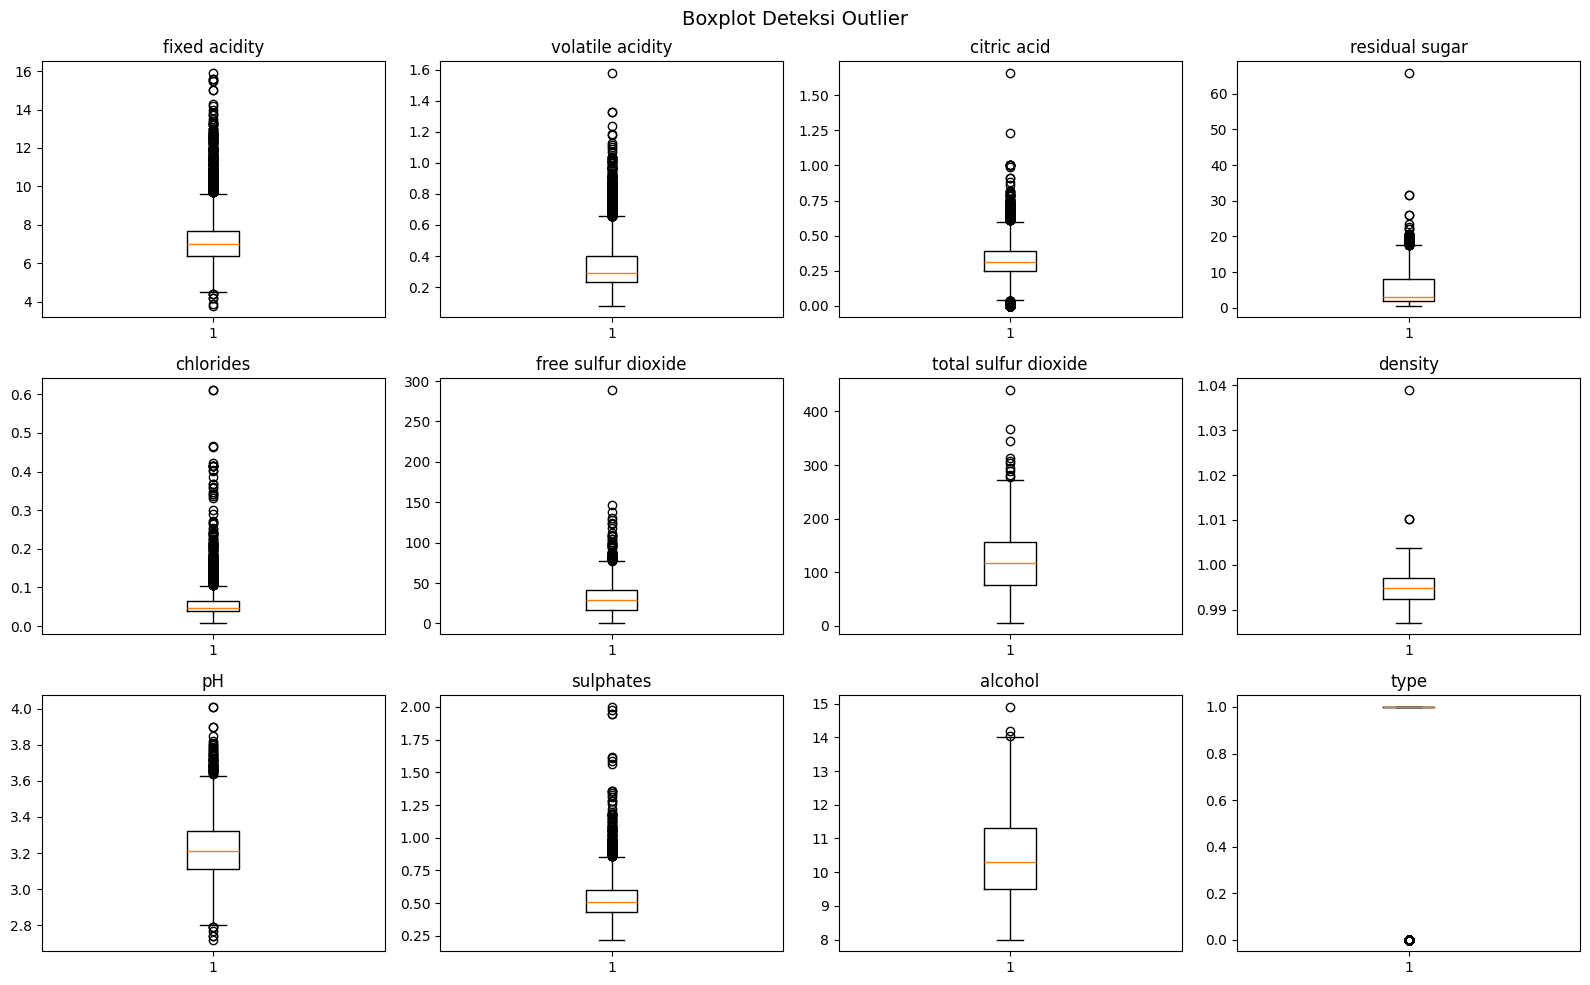

Boxplot outlier disimpan


In [ ]:
feature_cols = [col for col in df.columns if col != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14)
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150)
plt.show()
print("Boxplot outlier disimpan")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
df_processed = df.copy()

before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
after = df_processed.shape[0]
print(f"Hapus duplikat: {before} → {after} baris ({before-after} dihapus)")

print(f"Missing values: {df_processed.isnull().sum().sum()} (tidak ada)")

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[
            (df_clean[col] >= lower) & (df_clean[col] <= upper)
        ]
    return df_clean

feature_cols = [col for col in df_processed.columns if col != 'quality']
df_processed = remove_outliers_iqr(df_processed, feature_cols)
print(f"Hapus outlier (IQR): {after} → {df_processed.shape[0]} baris")

X = df_processed.drop('quality', axis=1)
y = df_processed['quality']
print(f"Fitur: {X.shape[1]} kolom | Target: {y.nunique()} kelas unik")
print(f"   Distribusi kelas:\n{y.value_counts().sort_index()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(" Standarisasi fitur selesai")

df_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
df_train_final['quality'] = y_train.values

df_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)
df_test_final['quality'] = y_test.values

df_train_final.to_csv('winequality_preprocessing.csv', index=False)
df_test_final.to_csv('winequality_test.csv', index=False)

print(f"\n Preprocessing selesai!")
print(f"   Train shape: {df_train_final.shape}")
print(f"   Test shape : {df_test_final.shape}")
print(f"\n File disimpan:")
print(f"   - winequality_preprocessing.csv")
print(f"   - winequality_test.csv")

Hapus duplikat: 6497 → 5320 baris (1177 dihapus)
Missing values: 0 (tidak ada)
Hapus outlier (IQR): 5320 → 3414 baris
Fitur: 12 kolom | Target: 7 kelas unik
   Distribusi kelas:
quality
3      11
4     109
5     938
6    1583
7     649
8     119
9       5
Name: count, dtype: int64

 Train: 2731 | Test: 683
 Standarisasi fitur selesai

 Preprocessing selesai!
   Train shape: (2731, 13)
   Test shape : (683, 13)

 File disimpan:
   - winequality_preprocessing.csv
   - winequality_test.csv
